# BERT intro

https://www.kaggle.com/models/tensorflow/bert/tensorFlow2/en-uncased-l-12-h-768-a-12/4?tfhub-redirect=true

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
import tensorflow_hub as hub
import tensorflow as tf
import tensorflow_text as text
import numpy as np

In [2]:
preprocessor = hub.KerasLayer("https://kaggle.com/models/tensorflow/bert/TensorFlow2/en-uncased-preprocess/3")
encoder = hub.KerasLayer("https://www.kaggle.com/models/tensorflow/bert/TensorFlow2/en-uncased-l-12-h-768-a-12/4",trainable=True)

### Preprocessor

In [32]:
texts =  ['nice movie indeed','I love python programming']
text_preprocessed = preprocessor(texts)
text_preprocessed.keys()

dict_keys(['input_type_ids', 'input_mask', 'input_word_ids'])

input_type_ids -> token ids

In [6]:
text_preprocessed['input_type_ids']

<tf.Tensor: shape=(2, 128), dtype=int32, numpy=
array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
      dtype=int32)>

input_mask -> attention mask (which tokens are real and which are padding)

In [7]:
text_preprocessed['input_mask']

<tf.Tensor: shape=(2, 128), dtype=int32, numpy=
array([[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
      dtype=int32)>

In [8]:
text_preprocessed['input_word_ids']

<tf.Tensor: shape=(2, 128), dtype=int32, numpy=
array([[  101,  3835,  3185,  5262,   102,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0, 

*   101 --> CLS token
*   102 --> SEP token

### Encoder

In [9]:
encoder_output = encoder(text_preprocessed)
encoder_output.keys()

dict_keys(['pooled_output', 'sequence_output', 'encoder_outputs', 'default'])

pooled_output -> vector representation for each sentence

In [10]:
encoder_output['pooled_output']

<tf.Tensor: shape=(2, 768), dtype=float32, numpy=
array([[-0.791774  , -0.21411909,  0.49769595, ...,  0.24465248,
        -0.47334474,  0.81758696],
       [-0.917123  , -0.4793516 , -0.7865695 , ..., -0.6175171 ,
        -0.71026856,  0.9218428 ]], dtype=float32)>

sequence_output -> vector representation for each token in the input

In [11]:
encoder_output['sequence_output']

<tf.Tensor: shape=(2, 128, 768), dtype=float32, numpy=
array([[[ 0.07292055,  0.08567822,  0.14476837, ..., -0.09677067,
          0.08722132,  0.07711101],
        [ 0.1783942 , -0.1900609 ,  0.50349414, ..., -0.05869763,
          0.32717133, -0.15578507],
        [ 0.18701527, -0.43388727, -0.48875186, ..., -0.15502739,
          0.00145194, -0.24470969],
        ...,
        [ 0.12083019,  0.12884212,  0.46453553, ...,  0.07375549,
          0.17441961,  0.16522165],
        [ 0.07967892, -0.01190671,  0.50225407, ...,  0.13777724,
          0.21002257,  0.00624547],
        [-0.07212661, -0.28303477,  0.5903341 , ...,  0.47551954,
          0.1666847 , -0.08920329]],

       [[-0.0790057 ,  0.3633508 , -0.21101609, ..., -0.17183742,
          0.16299754,  0.6724269 ],
        [ 0.27883506,  0.43716297, -0.35764715, ..., -0.04463629,
          0.38315165,  0.5887988 ],
        [ 1.2037677 ,  1.0727019 ,  0.4840876 , ...,  0.24920993,
          0.4073093 ,  0.404818  ],
        ...,

encoder_outputs -> outputs of all transfomer layers

In [13]:
len(encoder_output['encoder_outputs'])

12

# Text classification using BERT

In [15]:
import pandas as pd
df = pd.read_csv("spam.csv")
df.head(3)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [16]:
df.shape

(5572, 2)

In [17]:
df.Category.value_counts()

,count
Category,
ham,4825
spam,747


In [18]:
# Handling class imbalance through undersampling
df_spam = df[df['Category']=='spam']
df_ham = df[df['Category']=='ham']
df_ham = df_ham.sample(747)
df_spam.shape, df_ham.shape

((747, 2), (747, 2))

In [20]:
df = pd.concat([df_spam,df_ham])
df.Category.value_counts()

,count
Category,
spam,747
ham,747


In [21]:
# Mapping output column
df['Category'] = df['Category'].map({'spam':1,'ham':0})
df.head(3)

,Category,Message
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
5,1,FreeMsg Hey there darling it's been 3 week's n...
8,1,WINNER!! As a valued network customer you have...


In [22]:
from sklearn.model_selection import train_test_split
X = df['Message']
Y = df['Category']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, stratify=df['Category'])

In [24]:
# Import bert model
preprocessor = hub.KerasLayer("https://kaggle.com/models/tensorflow/bert/TensorFlow2/en-uncased-preprocess/3")
encoder = hub.KerasLayer("https://www.kaggle.com/models/tensorflow/bert/TensorFlow2/en-uncased-l-12-h-768-a-12/4",trainable=True)

In [25]:
# BERT layers
text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
preprocessed_text = preprocessor(text_input)
encoder_outputs = encoder(preprocessed_text)

# Neural network layers
layer_1 = tf.keras.layers.Dropout(0.1, name="dropout")(encoder_outputs['pooled_output'])
layer_2 = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(layer_1)

model = tf.keras.Model(inputs=[text_input], outputs=[layer_2])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
              loss='binary_crossentropy',
              metrics=['accuracy']
              )

In [28]:
with tf.device('/device:GPU:0'):
  model.fit(X_train, Y_train, epochs=1)

38/38 [==============================] - 31s 816ms/step - loss: 0.0029 - accuracy: 1.0000


In [29]:
model.evaluate(X_test, Y_test)

10/10 [==============================] - 5s 289ms/step - loss: 0.1624 - accuracy: 0.9632


[0.16241125762462616, 0.9632107019424438]

In [30]:
y_predicted = model.predict(X_test)
y_predicted = y_predicted.flatten()
y_predicted = np.where(y_predicted > 0.5, 1, 0)
y_predicted

10/10 [==============================] - 4s 302ms/step


array([1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0])

In [32]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       149
           1       0.96      0.97      0.96       150

    accuracy                           0.96       299
   macro avg       0.96      0.96      0.96       299
weighted avg       0.96      0.96      0.96       299



<Axes: >

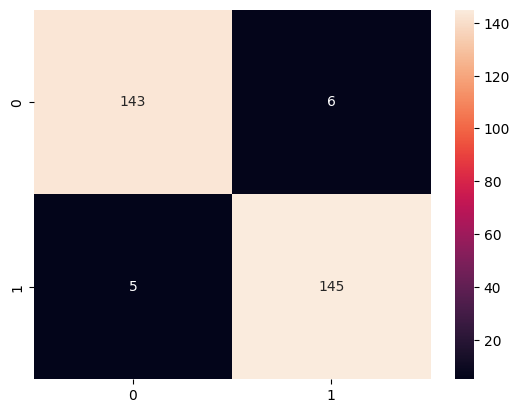

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(Y_test, y_predicted)
sns.heatmap(cm, annot=True, fmt='d')

In [34]:
# Inference
reviews = [
    'Enter a chance to win $5000, hurry up, offer valid until march 31, 2021',
    'You are awarded a SiPix Digital Camera! call 09061221061 from landline. Delivery within 28days. T Cs Box177. M221BP. 2yr warranty. 150ppm. 16 . p pÂ£3.99',
    'it to 80488. Your 500 free text messages are valid until 31 December 2005.',
    'Hey Sam, Are you coming for a cricket game tomorrow',
    "Why don't you wait 'til at least wednesday to see if you get your ."
]
model.predict(reviews)

1/1 [==============================] - 2s 2s/step


array([[0.99464583],
       [0.99851245],
       [0.99855834],
       [0.00220157],
       [0.00170337]], dtype=float32)